# Python Analysis on Bike Rental Demand


## Introduction

The following analysis examines the influence of day time, weekday type and weather-related attributes on hourly bike rental activity between October and December 2023 to identify key demand drivers and derive strategic recommendations on how the company can adjust operationally to maximize profits.

The dataset contains 1,096 hours of operational data including rental counts, weather-related variables, calendar flags for holidays and flags for non-operational business hours. To avoid bias the dataset was reduced by the number of non-operational hours, as these reflect zero-rental values caused by downtime, not by consumer behavior.

Three board-level questions guided the analysis. Why do customers rent bikes, are there ideal weather conditions that lead to demand peaks, and what strategic implications can be derived from the findings? The analysis followed a demand driver approach analyzing both temporal-, and environmental demand drivers.

The analysis showed that even though there are demand spikes during common commute time frames (7-9 am and (5-7pm), demand peaks towards the evening and reaches its highest values on the weekend suggesting that while commuters are an essential customer segment, demand is in fact leisure-heavy. Furthermore, temperatures of above 60 degrees Fahrenheit, Humidity below 60% and no rain provide can drive demand by 2.23x suggesting a need for dynamic fleet adjustments to minimize operational costs without sacrificing potential revenue on ideal-weather days.


## Question 1: Why are the majority of users renting bikes?

The data showed that demand is largely driven by afternoon and evening private use, with a smaller weekday morning commuter segment layered on top. Contrary to common believe of bikes being primarily used for commutes, the rental peaks between 5 and 7 pm with highest numbers on the weekend tell a different story. At 6pm for example, weekdays average 1,605 rentals versus 1,988 on the weekends, representing a 24% weekend surge. Rentals at 7am average 1,198 on weekdays outnumbering 1,152 on weekends so he commuter community is still an important factor, but less influential than initially thought. Holidays seemed to have little to no effect on demand, with only a 4% difference to non-holiday days recorded in the observed time frame. Since no data was available on whether a customer was a casual, one-time renter or a registered, returning customer, time of day seems to be the most reliable proxy for deriving reasons behind the rental.

Translating the numeric observations into real-life scenarios, evening demand is likely driven by post-work errands such as grocery shopping (transporting bags in bike basket), "commute" to after school and after work social gatherings or sports practices rather than commuter trips home, as workers who drive a bike home were unlikely to go to work by car (little to no one-way bike commutes expected).


## Question 2: Are there ideal weather conditions that create high demand?

Ideal weather conditions clearly create significantly higher demand for bike rentals within the observed time frame. A seasonal comparison however, cannot be conducted based on the available dataset.

The ideal weather condition combines temperatures over 60 degrees Fahrenheit, humidity below 60% and rain-free hours, on average generating 1,446 rentals per hour, compared to 649 in adverse (term used in analysis) conditions. This aligns with previous research findings that bike-share demands drop sharply when humidity exceeds 60% and that the temperature impact saturates above 17 degrees Celsius (Wang, 2025, p. 1). The correlation heatmap has shown temperature to be the most influential weather-related demand driver with a correlation with rentals of +0.46 with, followed by humidity with a negative correlation of -0.36. Warm hours (above 70F) and high humidity (>80%) directly change demand by 2.55x and 2.37x respectively. Snow and rain show low correlations due to low averages, but their per-event impact is still significant acting almost like a s "switch" for decisions against renting, as rainy hours collapse rental demand to 241 on average compared to 927 dry-hour rental averages.

The swing of average rentals per hour between ideal-weather and adverse-weather conditions sizes up to around 800 and at an assumed rental price point of $3.00 (Bluebikes, n.d.) for common bike-share providers, this translates to roughly $2,400 in revenue per peak hour. Therefore, weather-aware fleet management and dynamic adjustments to changing weather conditions are essential to operational efficiency and profitability.

The company should adjust fleet capacity dynamically based on next-day forecasts but can simplify their model to include only temperature, humidity and hour-of-day as forecasting metrics, as those three combined capture the majority of the predictable signals.


## Question 3: How should the company strategize?

Based on the analysis above, I derived four strategic recommendations to optimize the current business processes.

The highest-ROI adjustment is time-of-day fleet re-balancing. We need to deploy 100% of our fleet between 4pm and 8pm every day and scale back over night if possible (assumption that not 100% of fleet is owned but can be increased and decreased dynamically).

Second, is weather-based fleet sizing. Based on the same underlying assumption from above, we should deploy 100% of the fleet on forecasted ideal-weather days, 80% on mild and dry days, and 60% on cold or rainy days. Maintenance windows should then be placed dynamically on bad-weather days to avoid missing out on revenue on good-weather days.

The third suggestion is to re-evaluate the allocation of marketing budget (assumption is that it is currently centered around the peaks of commute times). It is important to maintain a strong message of reliability and easy alternative of commuting by car, but strong demand on weekends and evening suggest that a large group of customers uses bikes during leisure time and hence, a marketing campaign centering around biking as a "lifestyle" rather than choice of commute vehicle could be beneficial and boost demand in those areas even further.

Lastly, we should experiment with dynamic weather-reactive pricing to lower the variance on rental demand between good- and bad-weather days. This is especially important if the fleet size cannot be dynamically reduced based on time and weather conditions to avoid a large portion of the fleet to be unused, as this would force us to make a trade-off between having too much inventory (more bikes than demand, high cost) and too little inventory (can't meet demand, but low cost).


## Conclusion

The data provides valuable insights beyond the typical assumption of rental bikes being primarily a means of commute to and from work. The demand peaks during afternoon and evening and suggests primarily private after-work use both on weekdays and the weekend, with a commuter segment layered on top. This finding is further reinforced by the insignificance of the analyzed holiday effect.

Weather is another strong lever for demand forecasting, with temperatures above 70 Fahrenheit, humidity below 60% and no-rain forming ideal weather conditions boosting bike rental demand by 2.2x from adverse weather conditions' levels with rain and snow acting like a flip-switch with severe influence on renting decisions, though these factors' occurrence was relatively low.

Management should assess feasibility of the four proposed operational adjustments. Peak-hour and weather-triggered fleet rebalancing may help reduce costs without sacrificing potential revenue, whereas strong brand positioning towards leisure-driven customer bases may help establish the business as a "lifestyle"-brand and increase customer loyalty and retention. Lastly, discounts should be tested through low-engagement cycles, both caused by weather and off-peak hours) to lower the variance between best- and worst- performing days and effectively stabilize revenues.

It is important to keep in mind that the data collection period only captures October to December and therefore recommendations can not be generalized and implemented across seasons without further analysis. Additionally, adding data on first-time vs returning customers may help further clarify the separation between commute and leisure users.


## References

Bluebikes. (n.d.). Pricing. Bluebikes Boston. Retrieved May 22, 2026, from https://bluebikes.com/pricing

Wang, X. (2025). the impact of weather on shared bikes. Applied Sciences, 15(17), 9834. https://doi.org/10.3390/app15179834


## Python Setup, Package Import and Data Load

The dataset contains hourly bike rental statistics between October and December 2023 as well as weather-related information such as temperature, humidity, rain, etc. The data was used as the basis of our analysis to understand potential reasons for bike rentals and the weather conditions' influence on rental volume.

In [1]:
# importing packages used for statistical analysis & data viz
import pandas            as pd
import matplotlib.pyplot as plt
import seaborn           as sns


# importing user warnings (beware, warning does not equal error)
import warnings


# supressing user warnings to keep output tidy
warnings.simplefilter(action = 'ignore', category = UserWarning)


# specifying a file name
file = 'bikes_data.xlsx'


# reading the file into Python through pandas
bikes = pd.read_excel(io        = file,
                     sheet_name = 0,
                     header     = 0)


# outputting the first 5 rows of the dataset (for preview)
bikes.head(n = 5)

,ID,DateHour,Temperature(F),Humidity(%),Wind speed(mph),Visibility(miles),DewPointTemperature(F),Rainfall(in),Snowfall(in),SolarRadiation(MJ/m2),Holiday,FunctioningDay,RENTALS
0,mb_722,2023-10-01 00:59:56.000,65,52,2.9,1.3,48.7,0.0,0.0,0.00,No,Yes,655
1,mb_723,2023-10-01 02:59:56.000,63,52,3.4,2.0,46.6,0.0,0.0,0.00,No,Yes,274
2,mb_724,2023-10-01 04:59:56.000,60,54,2.9,2.1,45.9,0.0,0.0,0.00,No,Yes,271
3,mb_725,2023-10-01 05:59:56.000,63,55,2.7,2.3,46.0,0.0,0.0,0.00,No,Yes,658
4,mb_726,2023-10-01 06:59:56.365,62,55,3.1,2.3,45.9,0.0,0.0,0.07,No,Yes,1556


In [2]:
# reviewing data types and missing values
bikes.info(verbose = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1096 entries, 0 to 1095
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   ID                      1096 non-null   object        
 1   DateHour                1096 non-null   datetime64[ns]
 2   Temperature(F)          1096 non-null   int64         
 3   Humidity(%)             1096 non-null   int64         
 4   Wind speed(mph)         1096 non-null   float64       
 5   Visibility(miles)       1050 non-null   float64       
 6   DewPointTemperature(F)  1057 non-null   float64       
 7   Rainfall(in)            1096 non-null   float64       
 8   Snowfall(in)            1096 non-null   float64       
 9   SolarRadiation(MJ/m2)   1047 non-null   float64       
 10  Holiday                 1096 non-null   object        
 11  FunctioningDay          1096 non-null   object        
 12  RENTALS                 1096 non-null   int64   

### Dataset Shape

The dataset contains 1096 hourly observations of bike rentals and the weather conditions as well as a flag for functioning days and breakdown days that prohibited normal operations.

In [3]:
# descriptive statistics of numeric features
# rounded to 2 decimals for readability
bikes.describe(include = 'number').round(decimals = 2)

,Temperature(F),Humidity(%),Wind speed(mph),Visibility(miles),DewPointTemperature(F),Rainfall(in),Snowfall(in),SolarRadiation(MJ/m2),RENTALS
count,1096.00,1096.00,1096.00,1050.00,1057.00,1096.00,1096.00,1047.00,1096.00
mean,54.76,57.15,3.17,9.71,38.57,0.00,0.00,0.50,848.91
std,12.97,18.24,1.92,3.31,14.53,0.02,0.02,0.76,619.42
min,26.00,13.00,0.00,0.00,-2.20,0.00,0.00,0.00,0.00
25%,44.00,43.00,1.80,7.60,30.60,0.00,0.00,0.00,335.75
50%,53.00,58.00,2.90,11.40,38.50,0.00,0.00,0.00,774.00
75%,66.00,71.00,4.30,12.40,48.00,0.00,0.00,0.90,1201.25
max,86.00,97.00,12.80,12.40,69.80,0.36,0.30,2.96,3303.00


## Data Profile

The data sample used for the analysis spans 1,024 observations between October 1st and December 22nd, 2023, after excluding 72 hours from the original dataset where the rental system was not working. Including those non-operating hours would wrongfully bias the analysis towards zero.

The weather metrics Visibility, DewPointTemperature, and Solar Radiation show a small amount of missing values, but are still relevant for the correlation matrix, as Python handles missing values using pairwise omission and therefore no further adjustments are necessary.

Important to point out is that only about 5% of observations are flagged as holidays indicating the collection period is not biased by holiday-related effects (no school or work) but it it is important to acknowledge that the collection period only spans from October to December and therefore analysis of seasonal trends is limited.

In [4]:
# Analyzing the difference between holiday and non-holiday rentals
print('Holiday breakdown:')
print(bikes['Holiday'].value_counts(normalize = False,
                                   sort       = True,
                                   ascending  = False))


# empty print to create space between above and below print (similar logic applied later on)
print()


# ANalyzing how many hours the system was functioning vs broken down
print('Functioning days breakdown:')
print(bikes['FunctioningDay'].value_counts(normalize = False,
                                          sort       = True,
                                          ascending  = False))

Holiday breakdown:
Holiday
No     1044
Yes      52
Name: count, dtype: int64

Functioning days breakdown:
FunctioningDay
Yes    1024
No       72
Name: count, dtype: int64


### From Raw Data to Working Dataset

To allow for Hour-of-Day and Weekday-Type analysis, additional columns were created and the non-operational hours (system downtime, deficiency, etc.) were filtered out as these corresponding zero-rental values reflect system downtime and are not caused by actual user behavior.

In [5]:
# Create new analytical columnss through the use of iterrows + .loc
# Required as the original timestamp cannot be used to answer hour-of-day
# and weekday-vs-weekend questions (see Script 8 for reference)


# creating "dummy" columns to be populated by the for loop (iterrows)
# using '' for second and third column to avoid warning on incompatable dtype assigned
bikes['Hour']       = 0
bikes['DayType]']   = ''
bikes['TempBucket'] = ''


# using for loop to populate the newly created columns
for index, col in bikes.iterrows():
    
    # extracting the hours for hour-of-day from the original DateHour timestamp
    bikes.loc[index, 'Hour'] = bikes.loc[index, 'DateHour'].hour
    
    # assigning each timestamp to weekday or weekend
    if bikes.loc[index, 'DateHour'].weekday() < 5:
        bikes.loc[index, 'DayType'] = 'Weekday'
    else:
        bikes.loc[index, 'DayType'] = 'Weekend'
        
    # creating 4 buckets (bandwiths) to classify and compare temparature
    if bikes.loc[index, 'Temperature(F)'] < 40:
        bikes.loc[index, 'TempBucket'] = '1. Cold (<40F)'
    elif bikes.loc[index, 'Temperature(F)'] < 55:
        bikes.loc[index, 'TempBucket'] = '2. Cool (40-55F)'
    elif bikes.loc[index, 'Temperature(F)'] < 70:
        bikes.loc[index, 'TempBucket'] = '3. Mild (55-70F)'
    else:
        bikes.loc[index, 'TempBucket'] = '4. Warm (>=70F)'

        
# checking new columns exist and classification works by printing first five rows
bikes[['DateHour', 'Hour', 'DayType', 'Temperature(F)', 'TempBucket']].head(n = 5)

,DateHour,Hour,DayType,Temperature(F),TempBucket
0,2023-10-01 00:59:56.000,0,Weekend,65,3. Mild (55-70F)
1,2023-10-01 02:59:56.000,2,Weekend,63,3. Mild (55-70F)
2,2023-10-01 04:59:56.000,4,Weekend,60,3. Mild (55-70F)
3,2023-10-01 05:59:56.000,5,Weekend,63,3. Mild (55-70F)
4,2023-10-01 06:59:56.365,6,Weekend,62,3. Mild (55-70F)


In [6]:
# add a filter condition to filter for hours the system was working
# in effect excluding the non-operational hours of the system
functioning_condition = (bikes.loc[:, 'FunctioningDay'] == 'Yes')


# applying the filter
bikes_work = bikes[functioning_condition]


# checking the size of the adjusted dataset
print(f'Working dataset: {bikes_work.shape[0]} hours (removed {bikes.shape[0] - bikes_work.shape[0]} non-operational hours)')

Working dataset: 1024 hours (removed 72 non-operational hours)


## Question 1 - Rental behavior by Hour and Day-Type

The data doesn't provide any information on whether customers are casual renters, or registered, returning customers and therefore time and day type of their rental is the best proxy for why they are renting in the first place. First, we look at the hour-of-day demand split by weekday and weekend day type.

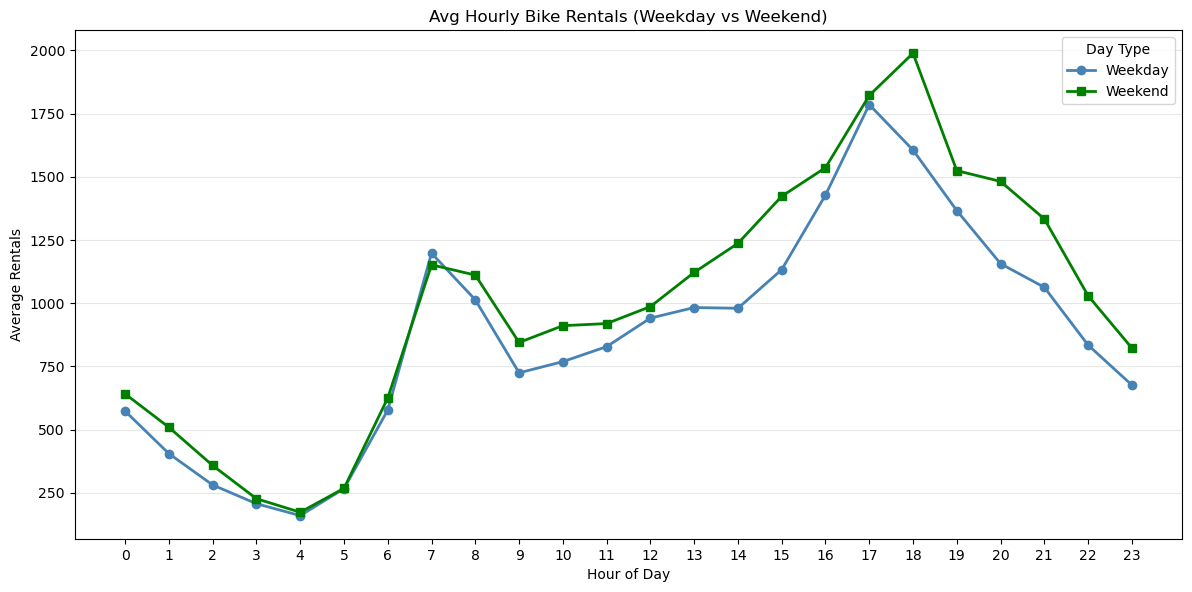

In [7]:
# For this visual i chose the line chart as a boxplot for every hour of day for two day types
# would have not been a fitting visualization and overload the viewer with information
# Creating lists to hold the hourly rental averages for weekday vs weekend
hours_list   = list(range(0, 24))
weekday_avgs = []
weekend_avgs = []

# calculating the average rentals by hour for weekday vs weekend
for hour in hours_list:
    
    # deefine filter conditions for each hour and day type (Weekday vs weekend)
    hour_condition    = (bikes_work.loc[:, 'Hour']    == hour)
    weekday_condition = (bikes_work.loc[:, 'DayType'] == 'Weekday')
    weekend_condition = (bikes_work.loc[:, 'DayType'] == 'Weekend')
    
    # subsetting the lsits and calculating the mean for each combination of hour and day type
    weekday_avgs.append(bikes_work[hour_condition][weekday_condition]['RENTALS'].mean())
    weekend_avgs.append(bikes_work[hour_condition][weekend_condition]['RENTALS'].mean())
    

# Defining the size of the graph for readability
fig, ax = plt.subplots(figsize = (12, 6))


# plotting the line for weekday averages by hour
plt.plot(hours_list,
        weekday_avgs,
        label     = 'Weekday',
        marker    = 'o',
        color     = 'steelblue',
        linewidth = 2)


# plotting the line for weekend averages by hour
plt.plot(hours_list,
        weekend_avgs,
        label     = 'Weekend',
        marker    = 's',
        color     = 'green',
        linewidth = 2)


# Additional formatting for the plot (axis labels, title, etc.)
plt.title(label      = 'Avg Hourly Bike Rentals (Weekday vs Weekend)')
plt.xlabel(xlabel    = 'Hour of Day')
plt.ylabel(ylabel    = 'Average Rentals')
plt.xticks(ticks     = hours_list)
plt.legend(title     = 'Day Type')
plt.grid(axis        = 'y', alpha = 0.3)
plt.tight_layout(pad = 1.0)


# visualizing (printing) the plot
plt.show(block = True)

### Visualization 1 - Rentals by Hour of Day and Weekend vs Weekday Split

Bike rentals spike twice a day, once in the morning between 7 and 9 am and once between 5 and 7 pm, indicating a strong reason for renting bikes may be commute. However, comparing weekday and weekend rentals shows that weekend rentals outnumber weekday rentals through almost every hour of the day suggesting that commute is not the only reason people rent. Another reason for morning rentals could be for day-trip visitors that rather rent in the morning to explore a full day as compared to renting later in the day. The evening surge could be enhanced by looser regulations on drinking and driving between car and bike use but cannot be verified based on the available data. The rental usage is minimal during the night (between 1 and 5 am), hence, the business should not allocate resources to work operations during those hours.

## Question 2 - Weather-related demand drivers

Building on the temporal drivers, we next analyzed the influence of environmental factors (specifically weather conditions) on bike rentals and determined the ideal operating conditions. The heatmap shows each weather-related attributes' linear relationship with rentals.

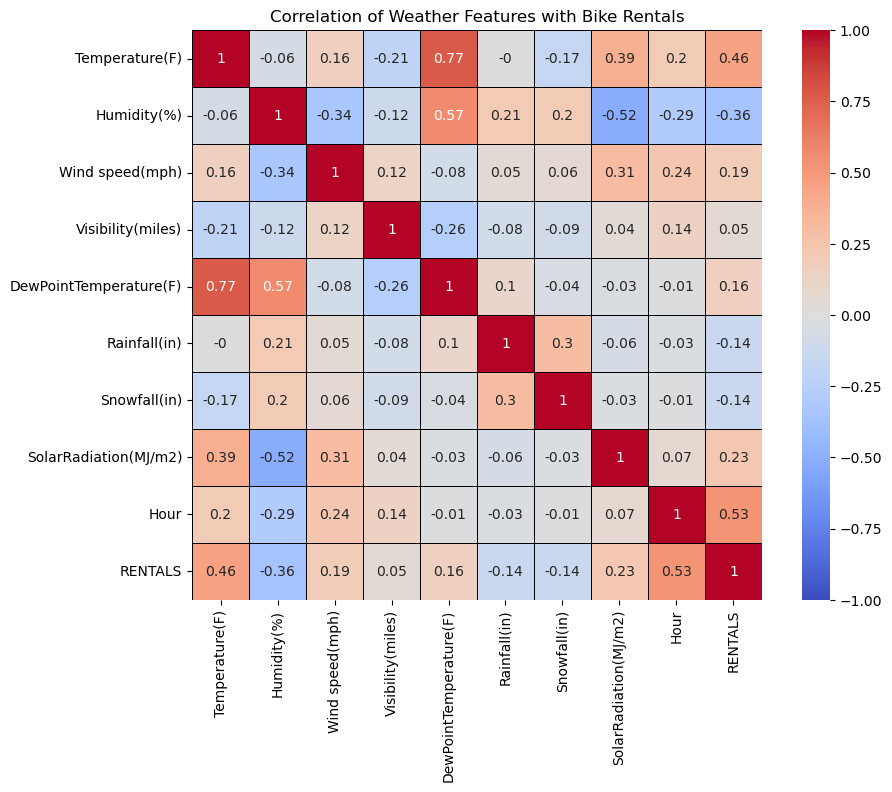

In [8]:
# Grouping the numeric weather features, Hour and RENTALS to be used for correlation matrix later on
weather_features = ['Temperature(F)',
                   'Humidity(%)',
                   'Wind speed(mph)',
                   'Visibility(miles)',
                   'DewPointTemperature(F)',
                   'Rainfall(in)',
                   'Snowfall(in)',
                   'SolarRadiation(MJ/m2)',
                   'Hour',
                   'RENTALS']


# Calculating the linear Pearon correlation matrix with corr & rounding to 2 decimals
bikes_corr = bikes_work[weather_features].corr(method = 'pearson').round(decimals = 2)


# Defining the size of the figure for better readability
fig, ax = plt.subplots(figsize = (10, 8))


# Defining the heatmap criteria and data based on bikes_corr with diverging color palette
sns.heatmap(data      = bikes_corr,
           cmap       = 'coolwarm',
           square     = True,
           annot      = True,
           linecolor  = 'black',
           linewidths = 0.5,
           vmin       = -1,
           vmax       = 1)


# adding title to the heatmap
plt.title(label = 'Correlation of Weather Features with Bike Rentals')


# showing (printing) the heatmap
plt.tight_layout(pad = 1.0)
plt.show(block = True)

### Visualization 2 - Correlation Heatmap

Though the Heatmap primarily aims to support the analysis of weather-related factors, it also reaffirms the previous analysis by validating that Hour (time of day) has the strongest correlation (+0.53) with rentals and should therefore be a driving factor when evaluating business processes.

Among the weather attributes, temperature is the single strongest influence on rentals with a correlation of +0.46, followed by humidity at -0.36 and solar radiation at +0.23. Other metrics show little to no useful linear relationship and for short-term demand forecasting, combining the two weather metrics temperature and humidity with the hour of day captures the majority of predictable consumer behavior signals and are therefore sufficient for next-day demand forecasting.

One aspect worth flagging is that temperature and DewPointTemperature have a strong positive correlation of +0.77 measuring overlapping physical signals and should therefore be treated as redundant in demand forecasting to avoid overestimation.

### Rental Demand by Temperature Buckets

Hourly rental demand climbs cleanly across four temperature buckets from cold to warm weather solidifying temperature as a main driver of demand.

/opt/homebrew/anaconda3/lib/python3.13/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


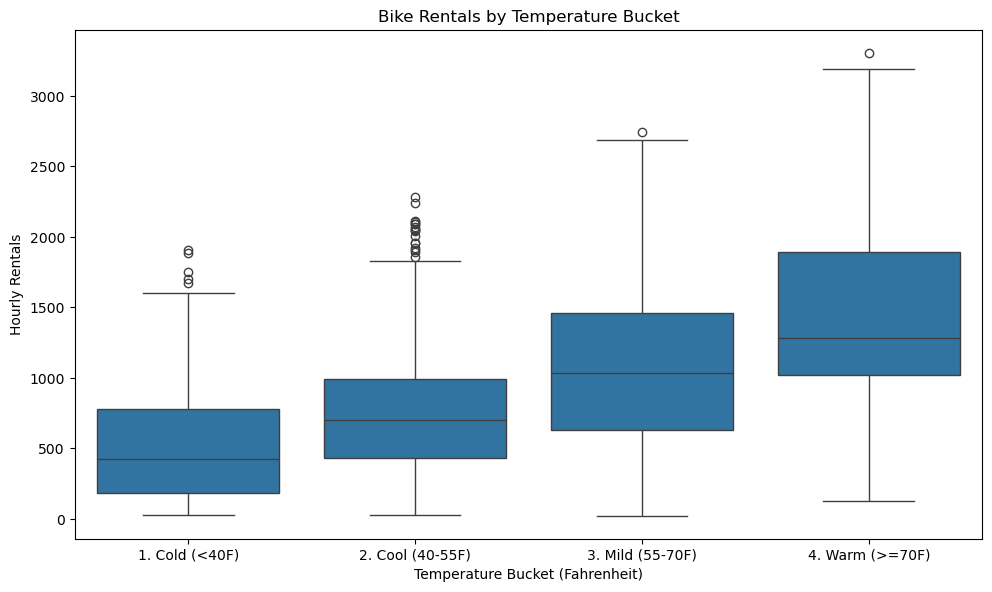

In [9]:
# Creating boxplot figure for additional insights on temprature influence on rentals
# defining the order of the temperature buckets, so that the visual reads cold to warm

# specifying plot size
fig, ax = plt.subplots(figsize = (10, 6))


temp_order = ['1. Cold (<40F)',
             '2. Cool (40-55F)',
             '3. Mild (55-70F)',
             '4. Warm (>=70F)']


# Defining the boxplot of rentals by temperature bucket
sns.boxplot(x    = 'TempBucket',
           y     = 'RENTALS',
           order = temp_order,
           data  = bikes_work)


# additional formatting for the plot
plt.title(label   = 'Bike Rentals by Temperature Bucket')
plt.xlabel(xlabel = 'Temperature Bucket (Fahrenheit)')
plt.ylabel(ylabel = 'Hourly Rentals')
plt.tight_layout(pad = 1.0)


#showing (printing) the plot
plt.show(block = True)

### Visualization 3 - Boxplot by Temperature Bucket

Median hourly rental increases without disruption from cold, to cool, to mild and peaks in warm weather. The median more than doubles between cold and warm weather and even the best performing days in cold weather perform well below the mild and warm weather median. Cold weather appears to have a performance cap or ceiling induced by temperature.

Additionally, the variance of the warm weather bucket is much higher suggesting that cold weather days are heavily restricted by the temperature and that seems to be the determining factor, whereas in warm weather, additional factors such as hour of day, humidity, etc. play a role in driving the gap between high- and low- rental volume days (within the warm weather bracket).

The strategic implication is clear. Warm weather lowers the physical barrier for riding and dynamic fleet adjustments should be base primarily on temperature forecasts.

### Ideal Operating Conditions

Temperature above 60(F), humidity below 60% and no rain provide ideal bike rental conditions.

The previous analysis has shown that both hours-of-day (line chart) and weather conditions (heatmap) significantly influence bike rentals. To derive actionable recommendations we must understand what "ideal" conditions would look like and analyze which components can be planned for and which require dynamic adaptation by the business.

In [10]:
# Defining and analyzing the "ideal" conditions
# warm enough to ride without feeling cold, low humidity and no rain
# will be used in matrix visual (condensed heatmap 2x2) later
warm_condition    = (bikes_work.loc[:, 'Temperature(F)']     >= 60)
dry_air_condition = (bikes_work.loc[:, 'Humidity(%)']        <= 60)
no_rain_condition = (bikes_work.loc[:, 'Rainfall(in)']       == 0)


# Defining the "adverse" conditions
# includes cold, or humid or rainy
cold_condition    = (bikes_work.loc[:, 'Temperature(F)']     < 50)
humid_condition   = (bikes_work.loc[:, 'Humidity(%)']        > 80)
rainy_condition   = (bikes_work.loc[:, 'Rainfall(in)']       > 0)


# subsetting the lsits and calculating the mean for each group
ideal_subset   = bikes_work[warm_condition][dry_air_condition][no_rain_condition]
adverse_subset = bikes_work[cold_condition | humid_condition | rainy_condition]


# print the rentals under ideal and adverse condition
# and calculate a demand multiplier driven by ideal conditions
# added ".0f" and ".2f" to specify decimal places for printed numbers to fit executive audience
print(f'Ideal conditions (T>=60F, H<=60%, no rain): avg = {ideal_subset["RENTALS"].mean():.0f} '
      f'(n = {ideal_subset.shape[0]} hours)')
print(f'Adverse conditions (T<=50F OR H>=80% OR rain): avg = {adverse_subset["RENTALS"].mean():.0f} '
      f'(n = {adverse_subset.shape[0]} hours)')
print(f'Demand multiplier (ideal vs adverse) : {ideal_subset["RENTALS"].mean() / adverse_subset["RENTALS"].mean():.2f}x')


Ideal conditions (T>=60F, H<=60%, no rain): avg = 1446 (n = 209 hours)
Adverse conditions (T<=50F OR H>=80% OR rain): avg = 649 (n = 523 hours)
Demand multiplier (ideal vs adverse) : 2.23x


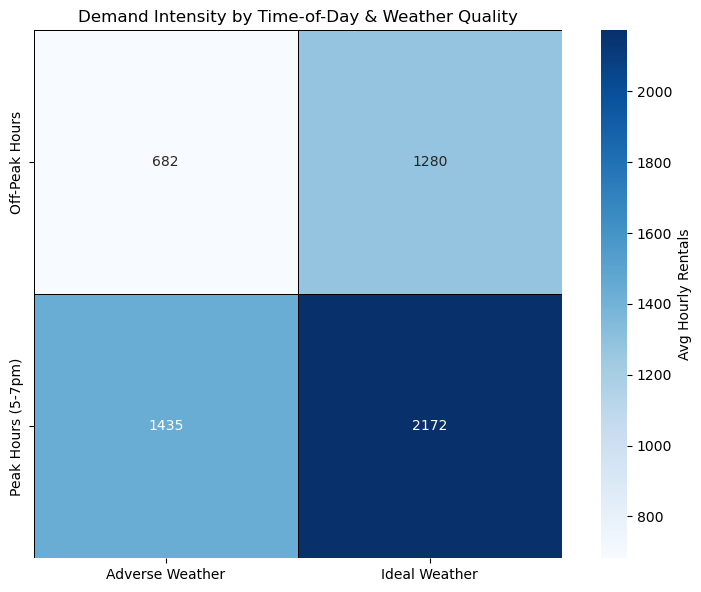

In [11]:
# Defining 4 quadrants for 2x2 heatmap matrix to show ideal and non ideal weather
# during peak and non-peak activity times


# Defining the conditions
peak_condition = ((bikes_work.loc[:, 'Hour'] >= 17) & (bikes_work.loc[:, 'Hour'] <= 19))

# offpeak is the opposite of peak_condition
offpeak_condition = ~peak_condition
ideal_w_condition = ((bikes_work.loc[:, 'Temperature(F)'] >= 60) &
                    (bikes_work.loc[:, 'Humidity(%)']     <= 60) &
                    (bikes_work.loc[:, 'Rainfall(in)']    == 0))

# adverse weather condition is everything that is not ideal weather condition
adverse_w_condition = ~ideal_w_condition


# defining the four quadrants and calculating the average rentals for each
peak_ideal      = bikes_work[peak_condition    & ideal_w_condition]['RENTALS'].mean()
peak_adverse    = bikes_work[peak_condition    & adverse_w_condition]['RENTALS'].mean()
offpeak_ideal   = bikes_work[offpeak_condition & ideal_w_condition]['RENTALS'].mean()
offpeak_adverse = bikes_work[offpeak_condition & adverse_w_condition]['RENTALS'].mean()


# combining the averages calculated above into a small dataframe
# to be used as data by the heatmap below (2x2)
demand_matrix = pd.DataFrame(data = {'Adverse Weather' : [offpeak_adverse, peak_adverse],
                                    'Ideal Weather' : [offpeak_ideal, peak_ideal]},
                            index = ['Off-Peak Hours', 'Peak Hours (5-7pm)'])


# specifying the figure size
fig, ax = plt.subplots(figsize = (8, 6))


# Defining the heatmap criteria and data based on demand_matrix
sns.heatmap(data      = demand_matrix,
           cmap       = 'Blues',
           square     = True,
           annot      = True,
           fmt        = '.0f',
           linecolor  = 'black',
           linewidths = 0.5,
           cbar_kws   = {'label': 'Avg Hourly Rentals'})


# additional formatting for the plot
plt.title(label   = 'Demand Intensity by Time-of-Day & Weather Quality')
plt.tight_layout(pad = 1.0)

### Visualization 4 - Demand Intensity Matrix

The most profitable operating quadrant (peak hours & ideal weather) averages 2,172 rentals per hour, around 3.19 times the amount of the worst operating quadrant (off-peak hours & adverse weather) signifying the importance of dynamically adjusting the amount of bikes available to upcoming weather forecasts. This allows the business to minimize costs by avoiding an excessive fleet on slow days without sacrificing revenue potential on days with peak-weather conditions.

Both levers, weather and hours contribute similar magnitude to the demand multiplier as ideal-weather leads to 1.5x amount of rentals compared to adverse-weather and peak-hours increase rental sales by 1.7x compared to off-peak hours of operation.

The hour of day component is influenced by rather constant demand rhythms (see hour-of-day line chart) driven by consumer routines bound to work, school and free time schedules, whereas weather is the more variable condition. Hence, operational optimizations should be two-dimensional, accounting for both, consistent consumer behavior and preferences, as well as dynamic weather adjustments.